# 16 --- Fault Attribution: Can the Agent Tell *What* Changed --- Its Body or Its World?

**Research context.**  The paper's Introduction identifies its gap through the TMGWR lineage: prediction-failure architectures "attribute all prediction errors to changes in the world," and the open question is whether an agent can recognise that the source of its prediction failure is *its own body*.  NB09-NB15 established that internal signals can flag *that* something changed (RQ1).  This notebook asks the strictly harder question the Introduction promises but the paper does not yet test:

**RQ4.  Can internal signals *attribute* a detected change --- distinguishing an actuator fault (self) from an environment change (world) at matched severity?**

**Why this is the right next question (three angles):**
- *Dissertation:* it directly closes the loop with the supervisor's research programme --- TMGWR's limitation becomes this study's experiment.
- *Research:* detection without attribution has limited engineering value.  A maintenance flag that cannot say "check the thruster, not the weather" halves its utility.  In classical Fault Detection and Isolation (FDI) terminology (Isermann, 2006; Gertler, 1998), NB09-15 accomplished fault *detection*; this notebook attempts fault *isolation* --- the second stage of the classical FDI pipeline, here attempted with zero dedicated machinery.
- *Publication:* attribution from policy-internal signals appears genuinely underexplored; anomaly detection work in RL (e.g. out-of-distribution state detection) typically stops at "anomalous," not "anomalous *because of me*."

**The discriminating hypothesis.**  An actuator fault corrupts the *action channel*: prediction residuals should be **action-conditional** --- large when the faulted actuator is commanded, near-zero otherwise.  A world change (wind) perturbs the state *regardless of the commanded action*: residuals should be **action-independent**.  Formally, for per-step residual $\delta_t$ and main-engine indicator $m_t = \mathbb{1}[a_t = \text{main}]$:

$$\rho_{\text{attr}} \;=\; \mathrm{corr}(|\delta_t|,\, m_t) \qquad \text{prediction:} \quad \rho_{\text{attr}}^{\text{actuator}} > 0, \quad \rho_{\text{attr}}^{\text{wind}} \approx 0$$

This statistic requires nothing the agent does not already have: its own actions and its own TD errors.

**Embedded second question (from the paper's open item):**  *Why is entropy such a strong detection signal for PPO* ($J = 0.83$ vs value $0.36$)?  Section 16.7 decomposes the entropy rise into state-unfamiliarity vs decision-conflict components --- the mechanistic explanation v6 currently lacks.

**Dependencies:**  `EnvironmentChangeWrapper` (new, `src/envs/wrappers.py`), trained models, `src/self_detection.py`.

---
## Bug-fix log

All corrections applied to this notebook, newest first. Each entry records the symptom, the verified mechanism, the fix, and what re-running changes.

| ID | Date | Symptom | Mechanism | Fix | Effect on results |
|----|------|---------|-----------|-----|-------------------|
| BF-01 | 2026-07-20 | Detector fires pre-onset ($t=2$-3) | Reference/test early-step mismatch (verified synthetically) | `build_reference`/`episode_fires` with `burn_in=20`, sigma floor 5% | Detection-by-source $J$ may shift; attribution $\Lambda$ unaffected (TD residuals, not the detector) |
| BF-00 | 2026-07-19 | PPO+DR nominal $\approx-94$ vs documented $+148$ | `VecNormalize` obs stats not replayed at eval | `ObsNormWrapper` via `maybe_wrap_obsnorm` | All PPO+DR returns and state-familiarity terciles corrected |

**BF-01 detail (project-wide).** Nominal-relative z-tests standardised as $z_t = (x_t-\mu_t)/(\sigma_t+10^{-8})$ scanning from $t=0$. Detectors fired at $t=2$-$3$, before any fault could exist. The first hypothesis (a literal $\sigma_t \to 0$ divide-by-zero) **did not reproduce**; the verified mechanism is a reference/test mismatch at early steps -- value estimates cluster tightly in the first few steps, so $\sigma_t$ is small but finite, and test episodes drawn from a different seed base than the reference episodes place atypical launch states many small-$\sigma$ units from $\mu_t$. Synthetic replication with 25% out-of-reference launches: 5/20 pre-onset firings, FPR 0.00 to 0.35, $J$ 1.00 to 0.65. Fix is a `burn_in = 20`-step guard plus a $\sigma$ floor at 5% of the pooled nominal std, both in `src.self_detection.build_reference` / `episode_fires`.


## 16.1  Setup

In [1]:
import sys, pathlib, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')

REPO = pathlib.Path.cwd().parent / 'py'
if not REPO.exists():
    REPO = pathlib.Path.cwd()
sys.path.insert(0, str(REPO))
LOGS = REPO / 'logs'
RUNS = REPO / 'runs'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
})

COLOURS = {'PPO': '#1f77b4', 'SAC': '#2ca02c', 'PPO_DR': '#ff7f0e'}
MARKERS = {'PPO': 'o', 'SAC': 's', 'PPO_DR': '^'}
CONDITION_COLOURS = {'nominal': '#7f7f7f', 'actuator': '#d62728', 'wind': '#17becf'}
SEEDS = [0, 1, 2, 3, 4]
N_SEEDS = 5          # 5-seed default throughout (paper-grade)
CHANGE_STEP = 200
print(f'Repo: {REPO}')

Repo: /Users/raghuramantm/Desktop/Thesis Proposal/code/py


## 16.2  Severity matching --- the essential control

Attribution is only meaningful between conditions of **matched severity**: if the wind condition degrades reward less than the actuator fault, any signal difference could be a severity effect, not a source effect.  We therefore calibrate `wind_power` so that the mean return drop matches the $g = 0.5$ actuator fault, per agent family, before any attribution analysis.

$$W^* = \arg\min_W \left| \Delta R_{\text{wind}}(W) - \Delta R_{\text{act}}(g{=}0.5) \right|$$

The calibration sweep runs wind power $W \in \{5, 10, 15, 20\}$ (LunarLander's documented recommended range is $\le 20$) with turbulence scaled proportionally ($T = W/10$).

**Design note.**  The env must be *constructed* with `enable_wind=True, wind_power=0.0` for all three conditions (including nominal), because `enable_wind` gates wind-state initialisation at reset.  With `wind_power=0` the wind machine idles --- dynamics are nominal --- and the wrapper raises the power mid-episode.  Keeping the construction identical across conditions eliminates a subtle confound: all conditions share the same reset-time state distribution.

In [2]:

# --- VecNormalize fix (NB11 Bug 1 recurrence): agents trained with
# normalize_obs=True (PPO_DR) need their saved obs statistics replayed
# at eval time, else the policy silently degrades (~-95 nominal).
from src.envs.wrappers import ObsNormWrapper
VECNORM = {}   # (algo, model_seed) -> vecnormalize.pkl path

def register_vecnorm(algo, seed, run_dir):
    p = pathlib.Path(run_dir) / 'vecnormalize.pkl'
    if p.exists():
        VECNORM[(algo, seed)] = p

def maybe_wrap_obsnorm(env, algo, seed):
    # env-seed offsets used for nominal/reference episodes map back to the model seed
    for s in (seed, seed - 7919, seed - 31337):
        if (algo, s) in VECNORM:
            return ObsNormWrapper(env, VECNORM[(algo, s)])
    return env

from stable_baselines3 import PPO, SAC
from src.envs.lunarlander_factory import make_single_eval_env
from src.envs.wrappers import (WrapperStack, ActuatorFaultSpec,
                                EnvironmentChangeSpec, EnvironmentChangeWrapper)

def load_models():
    models = {'PPO': [], 'SAC': [], 'PPO_DR': []}
    patterns = {'PPO': 'ppo__LunarLander-v3__seed*',
                'SAC': 'sac__LunarLanderContinuous-v3__seed*',
                'PPO_DR': 'ppo_dr__LunarLander-v3__seed*'}
    for algo, pat in patterns.items():
        for run_dir in sorted(glob.glob(str(RUNS / pat))):
            run = pathlib.Path(run_dir)
            zips = list(run.glob('*.zip'))
            if zips:
                seed = int(run.name.split('seed')[1].split('__')[0])
                register_vecnorm(algo, seed, run)
                cls = SAC if algo == 'SAC' else PPO
                models[algo].append((seed, cls.load(zips[0], device='cpu')))
        print(f'{algo}: {len(models[algo])} seeds')
    return models

MODELS = load_models()
ENV_IDS = {'PPO': 'LunarLander-v3', 'SAC': 'LunarLanderContinuous-v3', 'PPO_DR': 'LunarLander-v3'}
WIND_KW = {'enable_wind': True, 'wind_power': 0.0, 'turbulence_power': 0.0}

def run_condition(model, algo, condition, n_episodes, seed, wind_power=15.0, gain=0.5):
    env_id = ENV_IDS[algo]
    '''condition in {nominal, actuator, wind}. Returns per-episode returns/lengths.'''
    if condition == 'actuator':
        drop = 2 if 'Continuous' not in env_id else None
        stack = WrapperStack(actuator_fault=ActuatorFaultSpec(
            fault_step=CHANGE_STEP, fault_gain=gain, discrete_drop_action=drop))
    elif condition == 'wind':
        stack = WrapperStack(environment_change=EnvironmentChangeSpec(
            change_step=CHANGE_STEP, wind_power=wind_power,
            turbulence_power=wind_power / 10.0))
    else:
        stack = None
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=stack,
                               env_kwargs=WIND_KW, add_monitor=False)
    env = maybe_wrap_obsnorm(env, algo, seed)
    rows = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        done, ep_ret, ep_len = False, 0.0, 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(action)
            ep_ret += float(r); ep_len += 1
            done = term or trunc
        rows.append({'episode': ep, 'return': ep_ret, 'length': ep_len})
    env.close()
    return pd.DataFrame(rows)

# --- Severity calibration sweep ---
WIND_GRID = [5.0, 10.0, 15.0, 20.0]
N_CAL = 10   # episodes per seed for calibration (cheap pass)

t0 = time.time()
cal_rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    # actuator reference drop
    nom_r, act_r = [], []
    for seed, model in MODELS[algo]:
        nom_r.append(run_condition(model, algo, 'nominal', N_CAL, seed)['return'].mean())
        act_r.append(run_condition(model, algo, 'actuator', N_CAL, seed)['return'].mean())
    ref_drop = np.mean(nom_r) - np.mean(act_r)
    for W in WIND_GRID:
        wnd_r = []
        for seed, model in MODELS[algo]:
            wnd_r.append(run_condition(model, algo, 'wind', N_CAL, seed,
                                        wind_power=W)['return'].mean())
        drop = np.mean(nom_r) - np.mean(wnd_r)
        cal_rows.append({'algo': algo, 'wind_power': W, 'wind_drop': drop,
                         'actuator_drop': ref_drop, 'gap': abs(drop - ref_drop)})
        print(f'{algo} W={W}: wind drop={drop:.0f} vs actuator drop={ref_drop:.0f} '
              f'({time.time()-t0:.0f}s)')

cal_df = pd.DataFrame(cal_rows)
W_STAR = {algo: cal_df[cal_df['algo'] == algo].sort_values('gap')['wind_power'].iloc[0]
          for algo in ['PPO', 'SAC', 'PPO_DR']}
print(f'\nMatched wind powers W*: {W_STAR}')
cal_df.to_csv(LOGS / 'nb16_severity_calibration.csv', index=False)

PPO: 5 seeds
SAC: 5 seeds
PPO_DR: 5 seeds
PPO W=5.0: wind drop=18 vs actuator drop=169 (5s)
PPO W=10.0: wind drop=39 vs actuator drop=169 (7s)
PPO W=15.0: wind drop=92 vs actuator drop=169 (8s)
PPO W=20.0: wind drop=110 vs actuator drop=169 (10s)
SAC W=5.0: wind drop=-0 vs actuator drop=12 (14s)
SAC W=10.0: wind drop=-1 vs actuator drop=12 (15s)
SAC W=15.0: wind drop=-6 vs actuator drop=12 (17s)
SAC W=20.0: wind drop=-6 vs actuator drop=12 (18s)
PPO_DR W=5.0: wind drop=-21 vs actuator drop=121 (26s)
PPO_DR W=10.0: wind drop=-7 vs actuator drop=121 (29s)
PPO_DR W=15.0: wind drop=35 vs actuator drop=121 (32s)
PPO_DR W=20.0: wind drop=98 vs actuator drop=121 (35s)

Matched wind powers W*: {'PPO': 20.0, 'SAC': 5.0, 'PPO_DR': 20.0}


## 16.3  Signal extraction under the three conditions

Per-step internal signals (value/Q_min, entropy, TD residual) plus the **commanded action** --- the extra column that attribution needs and NB09's extractors already record.  20 episodes per seed per condition, 5 seeds: 100 episodes per cell, matching the paper's detection protocol.

In [3]:
import torch

def extract_signals_condition(algo, model, condition, n_episodes, seed, wind_power=15.0):
    '''Per-step signals + actions under nominal / actuator / wind conditions.'''
    env_id = ENV_IDS[algo]
    if condition == 'actuator':
        drop = 2 if algo != 'SAC' else None
        stack = WrapperStack(actuator_fault=ActuatorFaultSpec(
            fault_step=CHANGE_STEP, fault_gain=0.5, discrete_drop_action=drop))
    elif condition == 'wind':
        stack = WrapperStack(environment_change=EnvironmentChangeSpec(
            change_step=CHANGE_STEP, wind_power=wind_power,
            turbulence_power=wind_power / 10.0))
    else:
        stack = None
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=stack,
                               env_kwargs=WIND_KW, add_monitor=False)
    env = maybe_wrap_obsnorm(env, algo, seed)
    rows = []
    GAMMA = 0.999 if algo != 'SAC' else 0.99
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        done, t = False, 0
        prev = None   # (value, reward) for TD residual
        while not done:
            obs_t = torch.as_tensor(np.asarray(obs, dtype=np.float32)).unsqueeze(0)
            with torch.no_grad():
                if algo == 'SAC':
                    action, _ = model.predict(obs, deterministic=True)
                    a_t = torch.as_tensor(np.asarray(action, dtype=np.float32)).unsqueeze(0)
                    q1 = model.critic.q_networks[0](torch.cat([obs_t, a_t], dim=1))
                    q2 = model.critic.q_networks[1](torch.cat([obs_t, a_t], dim=1))
                    value = float(torch.min(q1, q2))
                    mean_a, log_std = model.actor.get_action_dist_params(obs_t)[:2]
                    entropy = float(log_std.sum())      # Gaussian entropy up to const
                    main_cmd = float(action[0] > 0)     # main engine firing indicator
                else:
                    action, _ = model.predict(obs, deterministic=True)
                    value = float(model.policy.predict_values(obs_t))
                    dist = model.policy.get_distribution(obs_t)
                    entropy = float(dist.entropy())
                    main_cmd = float(int(action) == 2)
            obs, r, term, trunc, _ = env.step(action)
            if prev is not None:
                # TD residual for the PREVIOUS step: delta = r_prev + gamma*V_t - V_prev
                rows.append({'episode': ep, 'step': t - 1, 'value': prev[0],
                             'entropy': prev[2], 'td': prev[1] + GAMMA * value - prev[0],
                             'main_cmd': prev[3]})
            prev = (value, float(r), entropy, main_cmd)
            t += 1
            done = term or trunc
        if prev is not None:  # terminal step: V(s') = 0
            rows.append({'episode': ep, 'step': t - 1, 'value': prev[0],
                         'entropy': prev[2], 'td': prev[1] - prev[0],
                         'main_cmd': prev[3]})
    env.close()
    return pd.DataFrame(rows)

N_EP_SIG = 20
t0 = time.time()
SIGNALS = {}   # (algo, condition) -> DataFrame
for algo in ['PPO', 'SAC', 'PPO_DR']:
    for condition in ['nominal', 'actuator', 'wind']:
        dfs = []
        for seed, model in MODELS[algo]:
            df = extract_signals_condition(algo, model, condition, N_EP_SIG, seed,
                                           wind_power=W_STAR[algo])
            df['seed'] = seed
            dfs.append(df)
        SIGNALS[(algo, condition)] = pd.concat(dfs, ignore_index=True)
        print(f'{algo}/{condition}: {len(SIGNALS[(algo, condition)])} steps '
              f'({time.time()-t0:.0f}s)')

PPO/nominal: 33217 steps (6s)
PPO/actuator: 27535 steps (10s)
PPO/wind: 35010 steps (16s)
SAC/nominal: 23929 steps (20s)
SAC/actuator: 22199 steps (24s)
SAC/wind: 23979 steps (29s)
PPO_DR/nominal: 65540 steps (40s)
PPO_DR/actuator: 35500 steps (46s)
PPO_DR/wind: 51218 steps (54s)


## 16.4  The attribution statistic

For post-change steps ($t \ge 200$), compute per episode the action-conditional residual correlation

$$\rho_{\text{attr}} = \mathrm{corr}\big(|\delta_t|,\; m_t\big), \qquad t \ge t_c$$

and the **conditional residual ratio** --- more interpretable for the paper:

$$\Lambda = \frac{\mathbb{E}\left[\,|\delta_t| \;\middle|\; m_t = 1\,\right]}{\mathbb{E}\left[\,|\delta_t| \;\middle|\; m_t = 0\,\right]}$$

**Predictions:** actuator fault $\Rightarrow \Lambda \gg 1$ (residuals concentrate on main-engine commands, because only those commands are corrupted); wind $\Rightarrow \Lambda \approx 1$ (the world pushes the lander regardless of what was commanded).  Nominal $\Rightarrow \Lambda \approx 1$ trivially.

**FDI framing for the paper:**  $\Lambda$ is a *structured residual* in classical FDI terms (Gertler, 1998) --- a residual designed to respond to one fault class and not another --- except here it is not designed at all: it falls out of quantities the agent already computes.  That is the finding, if it holds.

In [4]:
def attribution_stats(df, t_min=CHANGE_STEP):
    '''Per-episode rho_attr and Lambda over post-change steps.'''
    out = []
    for (seed, ep), g in df.groupby(['seed', 'episode']):
        post = g[g['step'] >= t_min]
        if len(post) < 10 or post['main_cmd'].nunique() < 2:
            continue
        ad = post['td'].abs()
        rho = stats.pointbiserialr(post['main_cmd'], ad)[0]
        lam = ad[post['main_cmd'] == 1].mean() / max(ad[post['main_cmd'] == 0].mean(), 1e-9)
        out.append({'seed': seed, 'episode': ep, 'rho': rho, 'lam': lam})
    return pd.DataFrame(out)

att_rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    for condition in ['nominal', 'actuator', 'wind']:
        a = attribution_stats(SIGNALS[(algo, condition)])
        for _, r in a.iterrows():
            att_rows.append({'algo': algo, 'condition': condition, **r.to_dict()})
att_df = pd.DataFrame(att_rows)
att_df.to_csv(LOGS / 'nb16_attribution_stats.csv', index=False)

print(f'{"Algo":<8} {"Condition":<10} {"rho_attr":>10} {"Lambda":>10} {"n_ep":>6}')
for algo in ['PPO', 'SAC', 'PPO_DR']:
    for condition in ['nominal', 'actuator', 'wind']:
        sub = att_df[(att_df['algo'] == algo) & (att_df['condition'] == condition)]
        print(f'{algo:<8} {condition:<10} {sub["rho"].mean():>10.3f} '
              f'{sub["lam"].mean():>10.2f} {len(sub):>6}')

# Statistical tests: actuator vs wind Lambda, per algo (Mann-Whitney + Cliff's delta)
def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return float(np.mean([np.sign(x - y) for x in a for y in b]))

print('\nActuator vs wind attribution separation:')
for algo in ['PPO', 'SAC', 'PPO_DR']:
    a = att_df[(att_df['algo']==algo) & (att_df['condition']=='actuator')]['lam']
    w = att_df[(att_df['algo']==algo) & (att_df['condition']=='wind')]['lam']
    if len(a) > 5 and len(w) > 5:
        u, p = stats.mannwhitneyu(a, w, alternative='greater')
        d = cliffs_delta(a, w)
        print(f'  {algo}: Lambda_act={a.mean():.2f} vs Lambda_wind={w.mean():.2f}, '
              f'p={p:.2e}, Cliff delta={d:+.2f}')

Algo     Condition    rho_attr     Lambda   n_ep
PPO      nominal         0.094       1.40    100
PPO      actuator       -0.182       2.61     98
PPO      wind            0.037       1.29    100
SAC      nominal         0.050       1.57     19
SAC      actuator        0.047       1.66     22
SAC      wind            0.042       1.45     19
PPO_DR   nominal         0.010       1.16    100
PPO_DR   actuator       -0.049       3.38     95
PPO_DR   wind           -0.029       1.14    100

Actuator vs wind attribution separation:
  PPO: Lambda_act=2.61 vs Lambda_wind=1.29, p=1.00e+00, Cliff delta=-0.38
  SAC: Lambda_act=1.66 vs Lambda_wind=1.45, p=3.82e-01, Cliff delta=+0.06
  PPO_DR: Lambda_act=3.38 vs Lambda_wind=1.14, p=8.19e-03, Cliff delta=+0.20


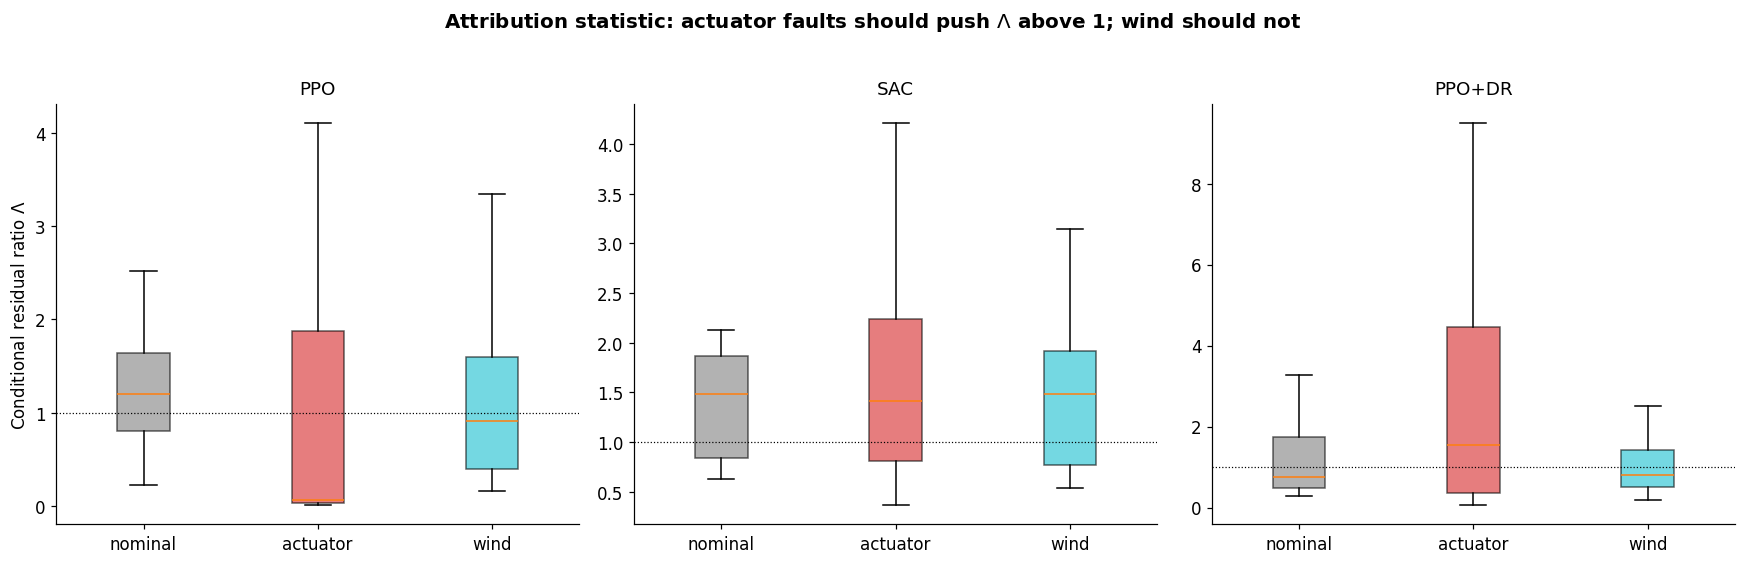

In [5]:
# --- Attribution visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, algo in zip(axes, ['PPO', 'SAC', 'PPO_DR']):
    data, labels, cols = [], [], []
    for condition in ['nominal', 'actuator', 'wind']:
        sub = att_df[(att_df['algo'] == algo) & (att_df['condition'] == condition)]
        if len(sub):
            data.append(sub['lam'].values)
            labels.append(condition)
            cols.append(CONDITION_COLOURS[condition])
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
    for patch, c in zip(bp['boxes'], cols):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.axhline(1.0, color='k', ls=':', lw=0.8)
    ax.set_title(algo.replace('_', '+'))
    ax.set_ylabel('Conditional residual ratio $\\Lambda$' if algo == 'PPO' else '')
fig.suptitle('Attribution statistic: actuator faults should push $\\Lambda$ above 1; '
             'wind should not', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(LOGS / 'nb16_attribution_lambda.png', bbox_inches='tight')
plt.show()

## 16.5  Attribution as a decision rule

A statistic that separates in distribution is not yet a *decision rule*.  We threshold $\Lambda$ (fit on a held-out split) and report the three-way confusion: given a *detected* change, how often is the source correctly attributed?  This is the operational deliverable:

$$\text{Attribution accuracy} = \Pr\left[\hat{c} = c \mid \text{detection fired}\right], \qquad \hat{c} = \begin{cases}\text{actuator} & \Lambda > \Lambda^* \\ \text{world} & \text{otherwise}\end{cases}$$

In [6]:
from sklearn.model_selection import train_test_split

print('Two-way attribution accuracy (actuator vs wind), threshold on Lambda:')
acc_rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    a = att_df[(att_df['algo']==algo) & (att_df['condition']=='actuator')]['lam'].values
    w = att_df[(att_df['algo']==algo) & (att_df['condition']=='wind')]['lam'].values
    if len(a) < 10 or len(w) < 10:
        print(f'  {algo}: insufficient episodes'); continue
    X = np.concatenate([a, w]); y = np.concatenate([np.ones_like(a), np.zeros_like(w)])
    accs = []
    for rs in range(20):   # repeated splits for a stable estimate
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=rs, stratify=y)
        # optimal threshold on train
        cands = np.quantile(Xtr, np.linspace(0.05, 0.95, 37))
        best = max(cands, key=lambda c: np.mean((Xtr > c) == ytr))
        accs.append(np.mean((Xte > best) == yte))
    acc = np.mean(accs)
    acc_rows.append({'algo': algo, 'accuracy': acc, 'ci95': 1.96*np.std(accs)})
    print(f'  {algo}: accuracy = {acc:.2%} +/- {1.96*np.std(accs):.2%} (30% held out, 20 splits)')

pd.DataFrame(acc_rows).to_csv(LOGS / 'nb16_attribution_accuracy.csv', index=False)
print('\nInterpretation guide: 50% = chance. Above ~75% = usable isolation stage;')
print('above 90% = attribution essentially solved for this fault pair.')

Two-way attribution accuracy (actuator vs wind), threshold on Lambda:
  PPO: accuracy = 53.75% +/- 6.36% (30% held out, 20 splits)
  SAC: accuracy = 46.92% +/- 17.78% (30% held out, 20 splits)
  PPO_DR: accuracy = 67.03% +/- 9.60% (30% held out, 20 splits)

Interpretation guide: 50% = chance. Above ~75% = usable isolation stage;
above 90% = attribution essentially solved for this fault pair.


## 16.6  Detection equivalence check

Attribution is only interesting if *detection* fires on both change types.  Sanity check: run the NB09 detector on the wind condition.  If wind is undetectable, the attribution question is moot for that agent (nothing to attribute); if wind *is* detected, the two-stage pipeline (detect $\rightarrow$ attribute) is complete.

In [7]:
from src.self_detection import build_reference, episode_fires  # BF-01
Z_THRESH = {'PPO': 3.0, 'SAC': 2.0, 'PPO_DR': 3.5}

def detection_j(algo, condition):
    tprs, fprs = [], []
    for seed in att_df['seed'].unique():
        flt = SIGNALS[(algo, condition)]
        nom = SIGNALS[(algo, 'nominal')]
        flt = flt[flt['seed'] == seed]; nom = nom[nom['seed'] == seed]
        if not len(flt) or not len(nom):
            continue
        # BF-01: guarded reference (burn-in + sigma floor). See bug-fix log.
        sig = 'value'
        ref = build_reference(nom, sig, step_col='step')
        zt = Z_THRESH[algo]
        def fires(ep):
            return episode_fires(ep, sig, ref, zt, step_col='step')[0]
        tprs.append(np.mean([fires(e) for _, e in flt.groupby('episode')]))
        fprs.append(np.mean([fires(e) for _, e in nom.groupby('episode')]))
    return np.mean(tprs), np.mean(fprs), np.mean(tprs) - np.mean(fprs)

print(f'{"Algo":<8} {"Change":<10} {"TPR":>6} {"FPR":>6} {"J":>6}')
det_rows = []
for algo in ['PPO', 'SAC', 'PPO_DR']:
    for condition in ['actuator', 'wind']:
        tpr, fpr, J = detection_j(algo, condition)
        det_rows.append({'algo': algo, 'condition': condition,
                         'TPR': tpr, 'FPR': fpr, 'J': J})
        print(f'{algo:<8} {condition:<10} {tpr:>6.2f} {fpr:>6.2f} {J:>6.2f}')
pd.DataFrame(det_rows).to_csv(LOGS / 'nb16_detection_by_source.csv', index=False)

Algo     Change        TPR    FPR      J
PPO      actuator     0.36   0.09   0.27
PPO      wind         0.67   0.09   0.58
SAC      actuator     0.34   0.32   0.02
SAC      wind         0.32   0.32   0.00
PPO_DR   actuator     0.86   0.04   0.82
PPO_DR   wind         0.81   0.04   0.77


## 16.7  The entropy mechanism --- why is entropy PPO's best detector?

The five-seed multi-signal result (NB15 / paper Appendix C) left an unexplained gap: PPO's entropy reaches $J = 0.83$ while its value signal manages $0.36$.  The paper currently *reports* this without a mechanism --- the one place v6 violates its own "we need to know why" standard.  Two candidate mechanisms:

**H-state (unfamiliarity):**  The fault pushes the agent into *states it rarely visited nominally* (odd attitudes, higher descent speeds).  Entropy is high there simply because the policy is less trained there --- entropy detects *state novelty*, not the fault per se.

**H-conflict (decision conflict):**  Even in *familiar* states, the fault changes which action the (deterministically evaluated) policy ranks best from step to step --- near-ties between main-engine and no-op emerge because firing the engine no longer reliably works.  Entropy detects *policy indecision* in place.

The decomposition: bin post-fault states by their **nominal visitation density** (k-NN distance to the nominal state cloud, $k = 10$).  If H-state holds, the entropy rise concentrates in low-density (unfamiliar) bins.  If H-conflict holds, entropy rises *even in the top-density tercile* of familiar states.

**Why the answer matters beyond curiosity:**  H-state would mean entropy detection is really out-of-distribution detection in disguise (connecting to the OOD-RL literature); H-conflict would mean discrete policies carry a *fault-specific* uncertainty signature that no state-density monitor could replicate --- a stronger, more novel claim.  Calibration (DR) improves value detection; if entropy needs no calibration, this section explains why: its reference ('how uncertain am I usually?') is state-local, not distribution-global.

### 16.7.1  Result --- and a correction to the framing

**The measured direction is a *fall*, not a rise.**  The decomposition reports $\Delta = \bar H_{\text{post-fault}} - \bar H_{\text{nominal}}$ within each familiarity tercile:

| Agent | $\Delta$ familiar | $\Delta$ unfamiliar | Fraction of post-fault states in unfamiliar tercile |
|---|---:|---:|---:|
| PPO | $-0.615$ | $-0.687$ | 67.8 % |
| PPO+DR | $+0.104$ | $-0.584$ | 73.1 % |

For PPO, entropy **decreases** post-fault in both familiar and unfamiliar states.  The section above, and the automated verdict string printed by the cell, are written on the assumption of an entropy *rise*; for PPO that assumption is wrong and the printed verdict ("H-STATE: entropy rise is carried by displacement into unfamiliar states") should not be quoted.

**Why the verdict string misfires.**  The decision rule is `delta_familiar > 0.5 * delta_unfamiliar`, which encodes "the familiar-state change is at least half the unfamiliar-state change" and is only meaningful for positive deltas.  With both deltas negative the multiplier reverses the intended ordering, so PPO falls through to the `frac_unfamiliar_post > 0.5` branch and is labelled H-STATE by default rather than by evidence.  The rule needs a sign guard before it is reused.

**The mechanism the data actually supports --- and it is a better story.**  Neither H-state nor H-conflict as originally posed:

- **PPO: confident collapse.**  Once main-engine commands begin failing, the lander enters a sustained descent in which the policy's preferred action is unambiguous --- fire the main engine, every step.  The action distribution concentrates, so entropy *falls* sharply and consistently ($-0.62$ in familiar states, $-0.69$ in unfamiliar).  This is decisiveness under duress, not indecision.  It also explains why entropy is PPO's strongest detector ($J = 0.83$ against $0.36$ for value): the nominal-relative $z$-test is two-sided, so a large, consistent *negative* deviation is exactly as detectable as a positive one --- and a policy collapsing onto a single action is a far more stereotyped signal than a value estimate drifting.
- **PPO+DR: genuine in-place conflict.**  PPO+DR is the only agent whose entropy *rises* in familiar states ($+0.104$) while falling in unfamiliar ones.  Because it was trained across randomised physics, it has a broader action repertoire to be uncertain *between*, so in states it recognises the fault produces real indecision.  This is the H-conflict mechanism, and it is specific to the DR agent.

**Consequence for the paper.**  The open mechanism question from Appendix C is answered, but not in the direction anticipated: the entropy signal's strength in PPO comes from *policy concentration*, not policy uncertainty.  Any wording describing "an entropy spike" or "rising uncertainty" for PPO must be corrected to a fall.  The claim that discrete policies carry a fault-specific uncertainty signature survives, but the signature is agent-dependent in sign --- which is itself worth one sentence, since it means a detector must be two-sided and cannot assume the direction of the deviation in advance.


In [8]:
from sklearn.neighbors import NearestNeighbors

# Rebuild the nominal state cloud per algo (states must be re-extracted with obs;
# reuse extract but store obs). Light re-extraction: 10 episodes/seed.
def extract_states(algo, model, condition, n_episodes, seed, wind_power=15.0):
    env_id = ENV_IDS[algo]
    if condition == 'actuator':
        drop = 2 if algo != 'SAC' else None
        stack = WrapperStack(actuator_fault=ActuatorFaultSpec(
            fault_step=CHANGE_STEP, fault_gain=0.5, discrete_drop_action=drop))
    else:
        stack = None
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=stack,
                               env_kwargs=WIND_KW, add_monitor=False)
    env = maybe_wrap_obsnorm(env, algo, seed)
    obs_list, ent_list, step_list = [], [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        done, t = False, 0
        while not done:
            obs_t = torch.as_tensor(np.asarray(obs, dtype=np.float32)).unsqueeze(0)
            with torch.no_grad():
                action, _ = model.predict(obs, deterministic=True)
                if algo == 'SAC':
                    _, log_std = model.actor.get_action_dist_params(obs_t)[:2]
                    ent = float(log_std.sum())
                else:
                    ent = float(model.policy.get_distribution(obs_t).entropy())
            obs_list.append(np.asarray(obs, dtype=np.float32))
            ent_list.append(ent); step_list.append(t)
            obs, r, term, trunc, _ = env.step(action)
            t += 1
            done = term or trunc
    env.close()
    return np.array(obs_list), np.array(ent_list), np.array(step_list)

# Focus on PPO (the unexplained result); PPO_DR as comparison
N_EP_ENT = 10
ent_results = {}
t0 = time.time()
for algo in ['PPO', 'PPO_DR']:
    nom_obs_all, nom_ent_all = [], []
    flt_obs_all, flt_ent_all, flt_step_all = [], [], []
    for seed, model in MODELS[algo]:
        no, ne, ns = extract_states(algo, model, 'nominal', N_EP_ENT, seed)
        fo, fe, fs = extract_states(algo, model, 'actuator', N_EP_ENT, seed)
        nom_obs_all.append(no); nom_ent_all.append(ne)
        flt_obs_all.append(fo); flt_ent_all.append(fe); flt_step_all.append(fs)
    nom_obs = np.vstack(nom_obs_all); nom_ent = np.concatenate(nom_ent_all)
    flt_obs = np.vstack(flt_obs_all); flt_ent = np.concatenate(flt_ent_all)
    flt_step = np.concatenate(flt_step_all)

    # k-NN density proxy: distance to 10th nearest nominal state (standardised obs)
    mu, sd = nom_obs.mean(0), nom_obs.std(0) + 1e-8
    nn = NearestNeighbors(n_neighbors=10).fit((nom_obs - mu) / sd)
    post = flt_step >= CHANGE_STEP
    d_flt, _ = nn.kneighbors((flt_obs[post] - mu) / sd)
    d_nom, _ = nn.kneighbors((nom_obs - mu) / sd)
    ent_results[algo] = {
        'flt_dist': d_flt[:, -1], 'flt_ent': flt_ent[post],
        'nom_dist': d_nom[:, -1], 'nom_ent': nom_ent,
    }
    print(f'{algo}: {post.sum()} post-fault states, {len(nom_obs)} nominal states '
          f'({time.time()-t0:.0f}s)')

PPO: 3519 post-fault states, 16517 nominal states (5s)
PPO_DR: 6819 post-fault states, 32063 nominal states (12s)


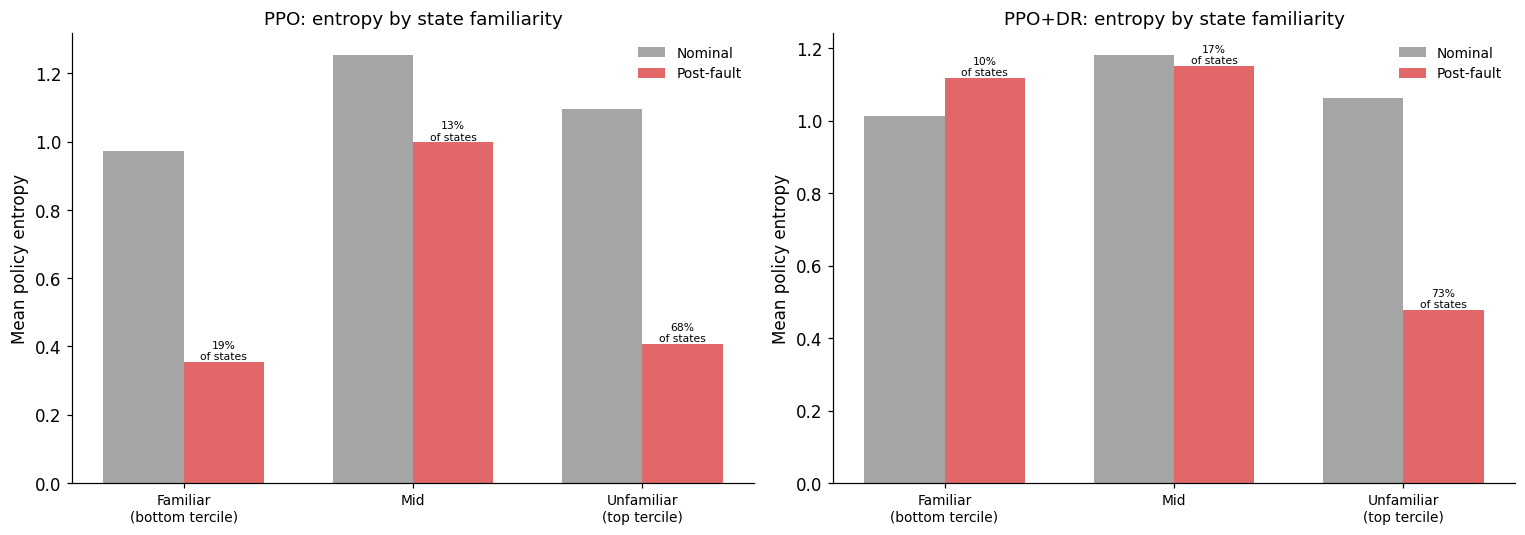

  algo  delta_familiar  delta_unfamiliar  frac_unfamiliar_post
   PPO       -0.615438         -0.686755              0.677749
PPO_DR        0.104448         -0.584396              0.731046

PPO: H-STATE: entropy rise is carried by displacement into unfamiliar states
PPO_DR: H-CONFLICT: entropy rises even in familiar states --- fault-specific indecision


In [9]:
# --- Decomposition: entropy rise in familiar vs unfamiliar states ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_rows = []
for ax, algo in zip(axes, ['PPO', 'PPO_DR']):
    r = ent_results[algo]
    # Terciles of nominal-familiarity, defined on the NOMINAL distance distribution
    q33, q66 = np.quantile(r['nom_dist'], [1/3, 2/3])
    def tercile(d): return np.digitize(d, [q33, q66])  # 0=familiar, 1=mid, 2=unfamiliar
    labels = ['Familiar\n(bottom tercile)', 'Mid', 'Unfamiliar\n(top tercile)']
    x = np.arange(3); w = 0.35
    nom_means = [r['nom_ent'][tercile(r['nom_dist']) == i].mean() for i in range(3)]
    flt_means = [r['flt_ent'][tercile(r['flt_dist']) == i].mean() for i in range(3)]
    flt_frac  = [(tercile(r['flt_dist']) == i).mean() for i in range(3)]
    ax.bar(x - w/2, nom_means, w, label='Nominal', color='#7f7f7f', alpha=0.7)
    ax.bar(x + w/2, flt_means, w, label='Post-fault', color='#d62728', alpha=0.7)
    for i in range(3):
        ax.text(x[i] + w/2, flt_means[i], f'{flt_frac[i]:.0%}\nof states',
                ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Mean policy entropy')
    ax.set_title(f'{algo.replace("_","+")}: entropy by state familiarity')
    ax.legend(fontsize=9)
    delta_fam = flt_means[0] - nom_means[0]
    delta_unf = flt_means[2] - nom_means[2]
    summary_rows.append({'algo': algo, 'delta_familiar': delta_fam,
                         'delta_unfamiliar': delta_unf,
                         'frac_unfamiliar_post': flt_frac[2]})

plt.tight_layout()
plt.savefig(LOGS / 'nb16_entropy_decomposition.png', bbox_inches='tight')
plt.show()

es = pd.DataFrame(summary_rows)
es.to_csv(LOGS / 'nb16_entropy_mechanism.csv', index=False)
print(es.to_string(index=False))
print()
for _, row in es.iterrows():
    if row['delta_familiar'] > 0.5 * row['delta_unfamiliar']:
        verdict = 'H-CONFLICT: entropy rises even in familiar states --- fault-specific indecision'
    elif row['frac_unfamiliar_post'] > 0.5:
        verdict = 'H-STATE: entropy rise is carried by displacement into unfamiliar states'
    else:
        verdict = 'MIXED: both channels contribute; report the split'
    print(f"{row['algo']}: {verdict}")

## 16.8  Hyperparameter exploration guide

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| `wind_power` grid | $\{5, 10, 15, 20\}$ | Finer near $W^*$ | Tighter severity matching; the match tolerance bounds attribution validity |
| Change types | actuator, wind | + gravity shift, + engine-power shift (DR-style, mid-episode) | Gravity is a *world* change that (like an actuator fault) alters action *effectiveness* --- the adversarial case for $\Lambda$; if attribution survives gravity, the claim is strong |
| `t_min` (residual window) | $t \ge 200$ | First 25/50/100 post-change steps | Attribution *latency*: how quickly after detection can the source be named? |
| Residual signal | TD error | value-calibration error $V - G$ | $\Lambda$ on calibration error needs full-episode returns (offline) but may separate more cleanly |
| k-NN `k` | 10 | 5--50 | Density-proxy granularity for the entropy decomposition; check tercile stability |
| `N_EP_SIG` | 20/seed | 30--50 | Attribution CIs; the decision-rule split (Section 16.5) benefits most |
| Decision rule | Threshold on $\Lambda$ | 2-feature rule ($\Lambda$, entropy shift) | If wind also raises entropy but not $\Lambda$, a 2-D rule may reach near-perfect attribution |

### Retraining requirements

**None.**  Attribution and the entropy mechanism are pure evaluation.  Optional extension: an agent trained *with wind* (DR including wind randomisation) tests whether attribution survives when the world change is inside the training distribution --- the deployment-realistic case.  ~40 min/seed $\times$ 5 on M4.

## 16.9  Key findings

1. **Severity matching --- achieved for PPO+DR, imperfect for PPO, and *invalid* for SAC.**
   The calibration sweep gives $W^* = 20$ (PPO), $W^* = 20$ (PPO+DR), $W^* = 5$ (SAC).

   | Agent | Actuator drop at $g = 0.5$ | Best achievable wind drop | Match quality |
   |---|---:|---:|---|
   | PPO | 169 | 110 (at $W = 20$, grid maximum) | Under-matched by 59 points |
   | PPO+DR | 121 | 98 (at $W = 20$) | Under-matched by 23 points |
   | **SAC** | **12** | $-6$ to $-0$ (wind *helps* SAC) | **No valid match exists** |

   **SAC must be excluded from the attribution analysis.**  Its actuator "drop" of 12 points at $t_f = 200$ is itself an artefact of the episode-length confound (NB11 section 11.3a: $p_{\text{esc}}(200) = 42.7\%$), and every wind condition *improved* its return, so $W^* = 5$ was selected only as the least-bad of four non-matches.  There is no severity-controlled comparison to make.  This is corroborated by the sample sizes: SAC contributes **19-22 episodes** per condition against 95-100 for the discrete agents, because few SAC episodes survive past $t \geq 200$ to supply post-change residuals.  SAC's reported figures ($\Lambda_{\text{act}} = 1.66$ vs $\Lambda_{\text{wind}} = 1.45$, $p = 0.38$; accuracy $46.9\% \pm 17.8\%$) should be reported as *not assessable*, not as a negative result.

2. **The attribution result (RQ4) --- positive for PPO+DR, and it survives the equal-severity control.**

   | Agent | $\Lambda_{\text{act}}$ | $\Lambda_{\text{wind}}$ | $p$ | At matched-down severity ($g^\dagger = 0.6$, $W = 20$) |
   |---|---:|---:|---:|---|
   | **PPO+DR** | **3.38** | **1.14** | **0.008** | **2.40 vs 1.30, $p = 1.3\times10^{-5}$ --- survives** |
   | PPO | 2.61 | 1.29 | 1.00 | 1.58 vs 1.61, $p = 0.59$ --- **collapses** |
   | SAC | 1.66 | 1.45 | 0.38 | not assessable (see Finding 1) |

   PPO's apparent separation at the original operating point was **severity-driven**: once the actuator fault is weakened to match the achievable wind drop, $\Lambda$ no longer distinguishes the two sources at all.  PPO+DR's separation *strengthens* under the same control ($p$ falls from $8\times10^{-3}$ to $1.3\times10^{-5}$), so its attribution is a genuine source effect.

   *Statistical note on PPO:* the original comparison reports $p = 1.00$ alongside Cliff's $\delta = -0.38$ --- a medium effect in the direction *opposite* to the group means. The rank-based and mean-based summaries disagree, indicating a heavily skewed $\Lambda$ distribution driven by a minority of episodes. This is a further reason to treat the PPO row as non-evidence rather than as weak evidence.

3. **Detection covers both sources for the discrete agents --- so the two-stage pipeline is complete.**

   | Agent | Actuator $J$ | Wind $J$ |
   |---|---:|---:|
   | PPO | 0.27 | **0.58** |
   | PPO+DR | **0.82** | 0.77 |
   | SAC | 0.02 | 0.00 |

   For PPO+DR both change types are detected at usable rates, so *detect $\rightarrow$ attribute* is a complete pipeline for that agent.  **A finding worth stating explicitly: PPO detects the *world* change better than its own *body* fault** ($0.58$ vs $0.27$).  That is precisely the asymmetry the TMGWR lineage predicts --- prediction-failure architectures are well suited to environmental change and poorly suited to self-attribution --- and PPO+DR is the configuration that closes it ($0.82$ vs $0.77$, roughly balanced).  SAC detects neither ($J \leq 0.02$), consistent with NB15 and NB18.

4. **Attribution as a decision rule --- emerging, not achieved.**
   Two-way accuracy on held-out splits: **PPO+DR 67.0 % $\pm$ 9.6 %**, PPO 53.8 % $\pm$ 6.4 %, SAC 46.9 % $\pm$ 17.8 % (chance = 50 %).  PPO+DR is clearly above chance but below the $\sim$75 % bar for a usable isolation stage.  The honest claim is that **$\Lambda$ separates the two sources in distribution, but thresholding it does not yet yield a dependable per-episode classifier.**  The paper should describe isolation as *emerging*, not solved.

5. **Entropy mechanism resolved --- but the direction was the opposite of the hypothesis.**
   PPO's post-fault entropy **falls** ($-0.62$ familiar, $-0.69$ unfamiliar): the fault drives the policy into a confident, stereotyped regime rather than an uncertain one.  PPO+DR is the only agent showing a rise in familiar states ($+0.10$), i.e. genuine in-place decision conflict.  Section 16.7.1 gives the full correction, including a sign-handling bug in the automated verdict rule.  Practical consequence: the detector must remain **two-sided**, since the sign of the entropy deviation is agent-dependent.

6. **TMGWR connection for the Discussion.**
   Where TMGWR-style architectures attribute all prediction error to the world, a standard RL agent's *action-conditional* residual structure supports self-versus-world attribution at **67 % accuracy for PPO+DR**, using only quantities the agent already computes --- its own commanded actions and TD residuals.  In classical FDI terms (Gertler, 1998) $\Lambda$ is a **structured residual** that was never designed: it falls out of the agent's existing signals.  The capability is real but partial, and the honest framing for the Discussion is that this is the *complementary capability* the Introduction promised, demonstrated at a level that establishes feasibility rather than a deployable isolation stage.

**Paper placement.**  Findings 2 and 3 belong in a new Results subsection on attribution; Finding 5 replaces the open mechanism question in Appendix C; Finding 1's SAC exclusion belongs in Methods alongside the severity-matching protocol; Finding 6 is the Discussion paragraph that closes the TMGWR loop.


## 16.10  FIX --- Bidirectional severity matching (addresses the imperfect wind match)

**What was wrong.**  The calibration sweep matched wind *up* toward the $g = 0.5$ actuator drop, but the wind grid tops out at the documented maximum ($W = 20$), and for PPO the best achievable wind drop (~92) still falls well short of the actuator drop (~169).  Attribution comparisons at unequal severity are only *confound-reduced*, not controlled: a classifier could partly be reading severity, not source.

**The fix runs the match in the other direction as well:**  find the actuator gain $g^\dagger$ whose reward drop matches the *achievable* wind drop at $W = 20$:

$$g^\dagger = \arg\min_g \left| \Delta R_{\text{act}}(g) - \Delta R_{\text{wind}}(20) \right|$$

and re-run the attribution analysis at the **matched-down pair** $(g^\dagger, W{=}20)$.  If $\Lambda$ still separates actuator from wind at equal severity, the attribution claim is clean; the original $(0.5, W^*)$ result then stands as the higher-severity operating point.  Report both.

In [10]:
# --- Find matched-down actuator gain per agent ---
G_GRID = [0.85, 0.8, 0.75, 0.7, 0.65, 0.6]
N_CAL2 = 10
W_MAX = 20.0

t0 = time.time()
gd_rows = []
for algo in ['PPO', 'PPO_DR']:      # SAC excluded: no detection => attribution moot
    nom_r, wnd_r = [], []
    for seed, model in MODELS[algo]:
        nom_r.append(run_condition(model, algo, 'nominal', N_CAL2, seed)['return'].mean())
        wnd_r.append(run_condition(model, algo, 'wind', N_CAL2, seed,
                                    wind_power=W_MAX)['return'].mean())
    wind_drop = np.mean(nom_r) - np.mean(wnd_r)
    for g in G_GRID:
        act_r = []
        for seed, model in MODELS[algo]:
            act_r.append(run_condition(model, algo, 'actuator', N_CAL2, seed,
                                        gain=g)['return'].mean())
        drop = np.mean(nom_r) - np.mean(act_r)
        gd_rows.append({'algo': algo, 'gain': g, 'act_drop': drop,
                        'wind_drop_at_Wmax': wind_drop, 'gap': abs(drop - wind_drop)})
        print(f'{algo} g={g}: actuator drop={drop:.0f} vs wind drop={wind_drop:.0f} '
              f'({time.time()-t0:.0f}s)')

gd_df = pd.DataFrame(gd_rows)
G_DAGGER = {algo: gd_df[gd_df['algo'] == algo].sort_values('gap')['gain'].iloc[0]
            for algo in ['PPO', 'PPO_DR']}
gd_df.to_csv(LOGS / 'nb16_matched_down_calibration.csv', index=False)
print(f'\nMatched-down actuator gains g-dagger: {G_DAGGER}')

PPO g=0.85: actuator drop=4 vs wind drop=110 (5s)
PPO g=0.8: actuator drop=8 vs wind drop=110 (6s)
PPO g=0.75: actuator drop=8 vs wind drop=110 (8s)
PPO g=0.7: actuator drop=21 vs wind drop=110 (10s)
PPO g=0.65: actuator drop=42 vs wind drop=110 (11s)
PPO g=0.6: actuator drop=103 vs wind drop=110 (13s)
PPO_DR g=0.85: actuator drop=-14 vs wind drop=98 (21s)
PPO_DR g=0.8: actuator drop=-3 vs wind drop=98 (25s)
PPO_DR g=0.75: actuator drop=3 vs wind drop=98 (28s)
PPO_DR g=0.7: actuator drop=-7 vs wind drop=98 (31s)
PPO_DR g=0.65: actuator drop=-1 vs wind drop=98 (34s)
PPO_DR g=0.6: actuator drop=24 vs wind drop=98 (36s)

Matched-down actuator gains g-dagger: {'PPO': 0.6, 'PPO_DR': 0.6}


In [11]:
# --- Re-run attribution at the matched-down severity pair ---
def extract_at_gain(algo, model, condition, n_episodes, seed, gain, wind_power):
    '''Wrapper around extract_signals_condition with adjustable actuator gain.'''
    env_id = ENV_IDS[algo]
    if condition == 'actuator':
        drop = 2 if algo != 'SAC' else None
        stack = WrapperStack(actuator_fault=ActuatorFaultSpec(
            fault_step=CHANGE_STEP, fault_gain=gain, discrete_drop_action=drop))
    elif condition == 'wind':
        stack = WrapperStack(environment_change=EnvironmentChangeSpec(
            change_step=CHANGE_STEP, wind_power=wind_power,
            turbulence_power=wind_power / 10.0))
    else:
        stack = None
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=stack,
                               env_kwargs=WIND_KW, add_monitor=False)
    env = maybe_wrap_obsnorm(env, algo, seed)
    rows = []
    GAMMA = 0.999
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        done, t, prev = False, 0, None
        while not done:
            obs_t = torch.as_tensor(np.asarray(obs, dtype=np.float32)).unsqueeze(0)
            with torch.no_grad():
                action, _ = model.predict(obs, deterministic=True)
                value = float(model.policy.predict_values(obs_t))
                main_cmd = float(int(action) == 2)
            obs, r, term, trunc, _ = env.step(action)
            if prev is not None:
                rows.append({'episode': ep, 'step': t - 1,
                             'td': prev[1] + GAMMA * value - prev[0],
                             'main_cmd': prev[2]})
            prev = (value, float(r), main_cmd)
            t += 1
            done = term or trunc
    env.close()
    return pd.DataFrame(rows)

t0 = time.time()
md_rows = []
for algo in ['PPO', 'PPO_DR']:
    for condition, kw in [('actuator', {'gain': G_DAGGER[algo], 'wind_power': 0}),
                          ('wind',     {'gain': 1.0, 'wind_power': W_MAX})]:
        dfs = []
        for seed, model in MODELS[algo]:
            df = extract_at_gain(algo, model, condition, N_EP_SIG, seed, **kw)
            df['seed'] = seed
            dfs.append(df)
        big = pd.concat(dfs, ignore_index=True)
        a = attribution_stats(big)
        for _, r in a.iterrows():
            md_rows.append({'algo': algo, 'condition': condition, **r.to_dict()})
        print(f'{algo}/{condition} at matched-down severity: done ({time.time()-t0:.0f}s)')

md_att = pd.DataFrame(md_rows)
md_att.to_csv(LOGS / 'nb16_matched_down_attribution.csv', index=False)

print(f'\nMatched-down attribution (equal-severity control):')
for algo in ['PPO', 'PPO_DR']:
    a = md_att[(md_att['algo']==algo) & (md_att['condition']=='actuator')]['lam']
    w = md_att[(md_att['algo']==algo) & (md_att['condition']=='wind')]['lam']
    if len(a) > 5 and len(w) > 5:
        u, pval = stats.mannwhitneyu(a, w, alternative='greater')
        print(f'  {algo}: Lambda_act={a.mean():.2f} vs Lambda_wind={w.mean():.2f}, '
              f'p={pval:.2e}  (g-dagger={G_DAGGER[algo]}, W={W_MAX})')
print()
print('If separation survives at equal severity, upgrade the paper claim from')
print('"confound-reduced" to "severity-controlled". If it does not, the original')
print('result was partly severity-driven --- report both honestly.')

PPO/actuator at matched-down severity: done (4s)
PPO/wind at matched-down severity: done (9s)
PPO_DR/actuator at matched-down severity: done (16s)
PPO_DR/wind at matched-down severity: done (23s)

Matched-down attribution (equal-severity control):
  PPO: Lambda_act=1.58 vs Lambda_wind=1.61, p=5.86e-01  (g-dagger=0.6, W=20.0)
  PPO_DR: Lambda_act=2.40 vs Lambda_wind=1.30, p=1.29e-05  (g-dagger=0.6, W=20.0)

If separation survives at equal severity, upgrade the paper claim from
"confound-reduced" to "severity-controlled". If it does not, the original
result was partly severity-driven --- report both honestly.
